In [53]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import seaborn as sns

# Pre-Processing Data

## Functions

In [54]:
def load(fnm):
	return json.load(open(fnm))

def pre_proccess_data_from_choice_vs_no_choice(data):
    output = []

    for block_num, block in enumerate(data['blocks']):
        if block_num == 0:
            continue

        try:
            block_drift = block['block_config']['params']['startCameraMode']
        except (KeyError, TypeError):
            block_drift = 0

        game_states = block.get('game_states', {})
        state_times = np.array(game_states.get('time', []))
        ball_y_coords = np.array(game_states.get('ball_y', []))
        camera_y_coords = np.array(game_states.get('camera_y', []))
        
        trials = block['trials']

        for i in range(len(trials) // 3):
            try:
                tier1_event_time = trials[3*i]['events'][0]['time']
                
                if len(state_times) > 0:

                    closest_state_idx = np.abs(state_times - tier1_event_time).argmin()
                    relative_ball_y = float(ball_y_coords[closest_state_idx] - camera_y_coords[closest_state_idx])
                else:
                    relative_ball_y = None


                choice_trial_sequence = [
                    trials[3*i]['hole_locations'],
                    trials[3*i+1]['hole_locations'],
                    trials[3*i+2]['hole_locations']
                ]
                
                chosen_path = [
                    trials[3*i]['events'][0]['holeUsed'], 
                    trials[3*i+1]['events'][0]['holeUsed'],
                    trials[3*i+2]['events'][0]['holeUsed']
                ]
                
                observed_rt = trials[3*i+2]['events'][0]['time'] - trials[3*i]['events'][0]['time']
                
                # does the middle trial have two options
                is_choice = len(trials[3*i+1]['hole_locations']) == 2

                if is_choice:
                    options = trials[3*i+1]['hole_locations']
                    chosen_hole = trials[3*i+1]['events'][0]['holeUsed']
                    
                    unchosen_hole = options[0] if options[0] != chosen_hole else options[1]
                    
                    non_chosen_path = [
                        trials[3*i]['events'][0]['holeUsed'], 
                        unchosen_hole, 
                        trials[3*i+2]['events'][0]['holeUsed']
                    ]
                    
                    chosen_1step_dist = abs(chosen_path[1] - chosen_path[0])
                    unchosen_1step_dist = abs(non_chosen_path[1] - non_chosen_path[0])
                    
                    chosen_2step_dist = chosen_1step_dist + abs(chosen_path[2] - chosen_path[1])
                    unchosen_2step_dist = unchosen_1step_dist + abs(non_chosen_path[2] - non_chosen_path[1])
                    
                else:
                    non_chosen_path = None
                    chosen_1step_dist = None
                    unchosen_1step_dist = None
                    chosen_2step_dist = None
                    unchosen_2step_dist = None
                
                output.append({
                    'block_number': block_num,
                    'trial_sequence_number': i,
                    'hole_sequence': choice_trial_sequence,
                    'chosen_path': chosen_path,
                    'non_chosen_path': non_chosen_path,
                    'observed_rt': observed_rt,
                    'choice_trial': is_choice,
                    'chosen_1step_dist': chosen_1step_dist,
                    'unchosen_1step_dist': unchosen_1step_dist,
                    'chosen_2step_dist': chosen_2step_dist,
                    'unchosen_2step_dist': unchosen_2step_dist,
                    'block_drift': block_drift,
                    'ball_y_at_top': relative_ball_y
                })
            except (KeyError, IndexError, TypeError) as e:
                continue

    output = pd.DataFrame(output)

    Q1 = output['observed_rt'].quantile(0.25)
    Q3 = output['observed_rt'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 2.5 * IQR
    upper_bound = Q3 + 2.5 * IQR
    
    output = output[(output['observed_rt'] >= lower_bound) & (output['observed_rt'] <= upper_bound)]
    output = output.reset_index(drop=True)

    chosen_middle = output['chosen_path'].str[1]
    unchosen_middle = output['non_chosen_path'].str[1]
    output['chosen_left'] = (chosen_middle < unchosen_middle)

    prev_end_hole = output['chosen_path'].shift(1).str[2]
    curr_start_hole = output['chosen_path'].str[0]
    direction = np.sign(prev_end_hole - curr_start_hole)

    prev_seq_num = output['trial_sequence_number'].shift(1)
    curr_seq_num = output['trial_sequence_number']

    prev_block = output['block_number'].shift(1)
    curr_block = output['block_number']

    is_valid_sequence = (prev_seq_num + 1 == curr_seq_num) & (prev_block == curr_block)

    output['incoming_direction'] = np.where(is_valid_sequence, -direction, np.nan)

    output = output.dropna(subset=['incoming_direction']).reset_index(drop=True)

    return output

In [67]:
def prepare_rnn_tensors(raw_data, batch_size=1, test_split=0.2):
    """
    Processes raw maze data and splits it into chronologically separated 
    training and testing dataloaders based on a target percentage of total trials.
    """
    processed_data = pre_proccess_data_from_choice_vs_no_choice(raw_data)
    
    if isinstance(processed_data, list):
        df_raw = pd.DataFrame(processed_data)
    else:
        df_raw = processed_data
        
    is_left = df_raw['chosen_left'].astype(bool)
    
    L1 = np.where(is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    R1 = np.where(~is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    
    chosen_2step_diff = df_raw['chosen_2step_dist'] - df_raw['chosen_1step_dist']
    unchosen_2step_diff = df_raw['unchosen_2step_dist'] - df_raw['unchosen_1step_dist']
    
    L2 = np.where(is_left, chosen_2step_diff, unchosen_2step_diff)
    R2 = np.where(~is_left, chosen_2step_diff, unchosen_2step_diff)

    X = pd.DataFrame({
        'L1-R1': L1 - R1,
        'L2-R2': L2 - R2,
        'block_drift': df_raw['block_drift'],
        'block_number': df_raw['block_number'],
        'chosen_left': df_raw['chosen_left'],
        'ball_y': df_raw['ball_y_at_top'],
        'cost': df_raw['observed_rt']
    })

    ball_y_mean = X['ball_y'].mean()
    ball_y_std = X['ball_y'].std()

    X['ball_y'] = (X['ball_y']-ball_y_mean)/ball_y_std

    trials_per_block = X.groupby('block_number').size()
    large_blocks = trials_per_block[trials_per_block > 4].index
    
    if not large_blocks.empty:
        first_real_block = large_blocks.min()
        X = X[X['block_number'] >= first_real_block].copy()

    for col in ['L1-R1', 'L2-R2', 'cost']:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        
    X = X.dropna(subset=['L1-R1', 'L2-R2', 'cost', 'chosen_left', 'ball_y'])

    max_time = X['cost'].max()
    min_time = X['cost'].min()
    X['cost'] = (X['cost'] - min_time) / (max_time - min_time + 1e-6)

    valid_trials_per_block = X.groupby('block_number').size().sort_index()
    
    if test_split > 0.0:
        cumulative_trials = valid_trials_per_block.cumsum()
        total_trials = cumulative_trials.iloc[-1]
        
        train_threshold = total_trials * (1 - test_split)
        
        train_blocks = set(valid_trials_per_block[cumulative_trials <= train_threshold].index)
        test_blocks = set(valid_trials_per_block[cumulative_trials > train_threshold].index)
        
        if len(test_blocks) == 0 and len(valid_trials_per_block) > 1:
            test_blocks = {valid_trials_per_block.index[-1]}
            train_blocks = set(valid_trials_per_block.index[:-1])
    else:
        train_blocks = set(valid_trials_per_block.index)
        test_blocks = set()

    feature_cols = ['L1-R1', 'L2-R2', 'block_drift', 'ball_y', 'cost']

    def build_tensors(target_blocks, is_train=True):
        features_list = []
        targets_list = []
        
        for b in sorted(target_blocks):
            group = X[X['block_number'] == b].sort_index()
            features_list.append(torch.tensor(group[feature_cols].values, dtype=torch.float32))
            targets_list.append(torch.tensor(group['chosen_left'].values, dtype=torch.long))
            
        if not features_list:
            return None, None, None
            
        x_pad = pad_sequence(features_list, batch_first=True, padding_value=0.0)
        y_pad = pad_sequence(targets_list, batch_first=True, padding_value=-1)
        
        dataset = TensorDataset(x_pad, y_pad)
        # We usually shuffle training blocks, but keep test blocks sequential for easier evaluation tracking
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        return x_pad, y_pad, loader

    # Build the distinct loaders
    X_train, y_train, train_loader = build_tensors(train_blocks, is_train=True)
    X_test, y_test, test_loader = build_tensors(test_blocks, is_train=False)

    print(f"-> Extracted {len(train_blocks)} Training Blocks, {len(test_blocks)} Testing Blocks.")
    
    if X_train is not None:
        print(f"-> Train X_padded shape: {X_train.shape} | Train y_padded shape: {y_train.shape}")
    if X_test is not None:
        print(f"-> Test X_padded shape:  {X_test.shape} | Test y_padded shape:  {y_test.shape}")

    # Returns two tuples: one for train, one for test
    return (X_train, y_train, train_loader), (X_test, y_test, test_loader)

## Loading

In [5]:
data = load("cloud study data/65D6694BE06947289BE4336BC1DE271A-019e9464-b9d3-798d-aa65-c87d82961db6-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-03-48-346Z-fg8d.json")

In [6]:
processed_data = pd.DataFrame(pre_proccess_data_from_choice_vs_no_choice(data))
processed_data = processed_data[processed_data['block_number'] > 4]

In [7]:
processed_data

,block_number,trial_sequence_number,hole_sequence,chosen_path,non_chosen_path,observed_rt,choice_trial,chosen_1step_dist,unchosen_1step_dist,chosen_2step_dist,unchosen_2step_dist,block_drift,ball_y_at_top,chosen_left,incoming_direction
0,5,1,"[[5], [0, 10], [2]]","[5, 0, 2]","[5, 10, 2]",2801.1,True,5,5,7,13,0,550.408631,True,-0.0
1,5,2,"[[4], [2, 7], [4]]","[4, 7, 4]","[4, 2, 4]",2967.4,True,3,2,6,4,0,516.241611,False,1.0
2,5,3,"[[5], [2, 11], [3]]","[5, 2, 3]","[5, 11, 3]",1950.7,True,3,6,4,14,0,516.271127,True,1.0
3,5,4,"[[4], [2, 11], [6]]","[4, 2, 6]","[4, 11, 6]",2016.5,True,2,7,6,12,0,516.281019,True,1.0
4,5,5,"[[4], [1, 11], [9]]","[4, 11, 9]","[4, 1, 9]",3298.8,True,7,3,9,11,0,516.241813,False,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,36,28,"[[5], [2, 10], [4]]","[5, 2, 4]","[5, 10, 4]",898.8,True,3,5,5,11,1,531.319158,True,-1.0
1026,36,29,"[[8], [3, 11], [6]]","[8, 3, 6]","[8, 11, 6]",1300.0,True,5,3,8,8,1,528.237178,True,1.0
1027,36,30,"[[9], [6, 11], [8]]","[9, 6, 8]","[9, 11, 8]",1916.6,True,3,2,5,5,1,495.278861,True,1.0
1028,36,31,"[[8], [6, 11], [8]]","[8, 6, 8]","[8, 11, 8]",867.8,True,2,3,4,6,1,483.707433,True,-0.0


In [8]:
X = pd.DataFrame({
    'L1': np.where(processed_data['chosen_left'], processed_data['chosen_1step_dist'], processed_data['unchosen_1step_dist']),
    'R1': np.where(~processed_data['chosen_left'], processed_data['chosen_1step_dist'], processed_data['unchosen_1step_dist']),
    
    'L2': np.where(processed_data['chosen_left'], 
                   processed_data['chosen_2step_dist'] - processed_data['chosen_1step_dist'], 
                   processed_data['unchosen_2step_dist'] - processed_data['unchosen_1step_dist']),
    'R2': np.where(~processed_data['chosen_left'], 
                   processed_data['chosen_2step_dist'] - processed_data['chosen_1step_dist'], 
                   processed_data['unchosen_2step_dist'] - processed_data['unchosen_1step_dist']),

    'block_drift': processed_data['block_drift']
})

X = pd.DataFrame({
    'L1-R1': X['L1']-X['R1'],
    'L2-R2': X['L2']-X['R2'],
    'block_drift': X['block_drift'],
    'block_number': processed_data['block_number'],
    'chosen_left': processed_data['chosen_left'],
    'cost': processed_data['observed_rt']
})

In [9]:
X

,L1-R1,L2-R2,block_drift,block_number,chosen_left,cost
0,0,-6,0,5,True,2801.1
1,-1,-1,0,5,False,2967.4
2,-3,-7,0,5,True,1950.7
3,-5,-1,0,5,True,2016.5
4,-4,6,0,5,False,3298.8
...,...,...,...,...,...,...
1025,-2,-4,1,36,True,898.8
1026,2,-2,1,36,True,1300.0
1027,1,-1,1,36,True,1916.6
1028,-1,-1,1,36,True,867.8


# RNNs and Training Functions

In [68]:
class TinyDecisionRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_actions):

        super(TinyDecisionRNN, self).__init__()
        
        self.hidden_size = hidden_size
        
        self.gru = nn.GRU(input_size=input_size, 
                          hidden_size=hidden_size, 
                          batch_first=True)

        self.readout = nn.Linear(in_features=hidden_size, 
                                 out_features=num_actions)

    def forward(self, x, h_0=None):

        gru_out, h_n = self.gru(x, h_0)
        
        logits = self.readout(gru_out)
        
        probabilities = torch.softmax(logits, dim=-1)
        
        return probabilities, h_n
    
def evaluate_model_performance(model, data_loader):
    model.eval()  # Switch model to evaluation mode
    
    total_log_likelihood = 0.0
    all_predictions = []
    all_actuals = []
    
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            h_0 = torch.zeros(1, batch_x.size(0), model.hidden_size)
            probabilities, _ = model(batch_x, h_0)
            
            for run_idx in range(batch_x.size(0)):
                run_probs = probabilities[run_idx].view(-1, model.readout.out_features)
                run_actuals = batch_y[run_idx].view(-1)
                
                for step_idx in range(run_probs.size(0)):
                    actual_action = run_actuals[step_idx].item()
                    
                    if actual_action == -1:
                        break
                        
                    if actual_action not in [0, 1]:
                        continue
                    
                    try:
                        chosen_prob = run_probs[step_idx][actual_action].item()

                        if np.isnan(chosen_prob) or chosen_prob == 0.0:
                            print(f"Something\'s wrong @ {run_idx}, Step {step_idx}!")
                        total_log_likelihood += np.log(max(chosen_prob, 1e-7))
                        
                        predicted_action = torch.argmax(run_probs[step_idx]).item()
                        
                        all_predictions.append(predicted_action)
                        all_actuals.append(actual_action)
                        
                    except IndexError as e:
                        print(f"Index alignment error at step {step_idx}: {e}")
                        continue
                    
    all_actuals = np.array(all_actuals)
    all_predictions = np.array(all_predictions)
           
    total_steps = len(all_actuals)
    accuracy = np.sum(all_predictions == all_actuals) / total_steps
    err_matrix = confusion_matrix(all_actuals, all_predictions, labels=[0, 1])

    
    return {
        "log_likelihood": total_log_likelihood/total_steps,
        "accuracy": accuracy,
        "error_matrix": err_matrix
    }

def train_RNN(model, train_loader, num_epochs=150, learning_rate=0.005, l1_lambda=1e-4):
    """
    Trains the TinyDecisionRNN model, applying L1 regularization to the 
    recurrent weights and gradient clipping to prevent explosion.
    """

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    

    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    
    model.train()
    
    epoch_losses = []
    
    for epoch in range(num_epochs):
        total_epoch_loss = 0.0
        
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()

            h_0 = torch.zeros(1, batch_x.size(0), model.hidden_size)
            
            gru_out, _ = model.gru(batch_x, h_0)
            logits = model.readout(gru_out) 
            
            logits = logits.view(-1, model.readout.out_features)
            batch_y = batch_y.view(-1)
            
            base_loss = criterion(logits, batch_y)
            
            l1_norm = sum(p.abs().sum() for name, p in model.named_parameters() if 'gru.weight' in name)
            loss = base_loss + (l1_lambda * l1_norm)
            
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            total_epoch_loss += loss.item()
            
        avg_loss = total_epoch_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        
        if (epoch + 1) % 25 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

    print("\nTraining Complete!")
    return model, epoch_losses

def run_RNN_for_eval(participant_data, num_epochs = 400):
    train_data, test_data = prepare_rnn_tensors(participant_data, batch_size=4, test_split=0.2)
    X_train, y_train, train_loader = train_data
    X_test, y_test, test_loader = test_data

    model_participant = TinyDecisionRNN(input_size=5, hidden_size=2, num_actions=2)
    model_participant, _ = train_RNN(model_participant, train_loader= train_loader, num_epochs= num_epochs)

    return evaluate_model_performance(model_participant, test_loader)

# Logistic Regression Functions

In [69]:
def run_logistic_regression_baseline(X, test_split=0.2):
    """
    Trains a Logistic Regression model as a memoryless baseline, 
    matching the RNN's chronological train/test split and metric outputs.
    """
    #print('run_logistic_regression_baseline input', X.shape)
    valid_trials_per_block = X.groupby('block_number').size().sort_index()
    cumulative_trials = valid_trials_per_block.cumsum()
    total_trials = cumulative_trials.values[-1]
    
    train_threshold = total_trials * (1 - test_split)
    
    train_blocks = valid_trials_per_block[cumulative_trials <= train_threshold].index
    test_blocks = valid_trials_per_block[cumulative_trials > train_threshold].index
    
    if len(test_blocks) == 0 and len(valid_trials_per_block) > 1:
        test_blocks = [valid_trials_per_block.index[-1]]
        train_blocks = valid_trials_per_block.index[:-1]

    train_df = X[X['block_number'].isin(train_blocks)]
    test_df = X[X['block_number'].isin(test_blocks)]
    
    features = [
        'L1-R1', 
        'L2-R2', 
        'Block Drift', 
        'Block Drift + L1-R1 Interaction', 
        'Block Drift + L2-R2 Interaction', 
        'Incoming Direction',
        'Block Drift + Incoming Direction Interaction',
    ]
    
    X_train = train_df[features]
    y_train = train_df['chosen_left'].astype(int)
    
    X_test = test_df[features]
    y_test = test_df['chosen_left'].astype(int)
    
    if len(X_test) == 0:
        print("❌ Error: No out-of-sample data available for testing.")
        return None

    log_reg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
    log_reg.fit(X_train, y_train)

    y_pred = log_reg.predict(X_test)
    
    probs = log_reg.predict_proba(X_test)
    
 
    chosen_probs = probs[np.arange(len(y_test)), y_test.values]

    total_log_likelihood = np.sum(np.log(chosen_probs + 1e-15))
    
    accuracy = accuracy_score(y_test, y_pred)
    err_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])
    total_steps = len(y_test)

    print("\n Predicting probability of going left")
    print("\n Incoming Direction = +1 if they\'re already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction")    

    print("\n Coefficients:")
    for feature, coef in zip(features, log_reg.coef_[0]):
        print(f"  {feature:<25}: {coef:.4f}")
    


    return {
        "model": log_reg,
        "log_likelihood": total_log_likelihood/total_steps,
        "accuracy": accuracy,
        "error_matrix": err_matrix
    }


def evaluate_logistic_baseline(raw_data, test_split=0.2, is_data_raw = True):
    """
    Takes raw participant data, processes all spatial metrics and interaction 
    terms, and evaluates it using a logistic regression baseline model.
    """

    if is_data_raw:
        processed_data = pre_proccess_data_from_choice_vs_no_choice(raw_data)
    else:
        processed_data = raw_data
        
    if isinstance(processed_data, list):
        df_raw = pd.DataFrame(processed_data)
    else:
        df_raw = processed_data
            
    is_left = df_raw['chosen_left'].astype(bool)
        
    L1 = np.where(is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    R1 = np.where(~is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])

    chosen_2step_diff = df_raw['chosen_2step_dist'] - df_raw['chosen_1step_dist']
    unchosen_2step_diff = df_raw['unchosen_2step_dist'] - df_raw['unchosen_1step_dist']

    L2 = np.where(is_left, chosen_2step_diff, unchosen_2step_diff)
    R2 = np.where(~is_left, chosen_2step_diff, unchosen_2step_diff)

    diff_1step_raw = L1 - R1
    diff_2step_raw = L2 - R2
    block_drift = df_raw['block_drift']

    X = pd.DataFrame({
        'diff_1step': diff_1step_raw,
        'diff_2step': diff_2step_raw,
        'Block Drift': block_drift,
        'block_number': df_raw['block_number'],
        'chosen_left': df_raw['chosen_left'].astype(int),
        'Incoming Direction': df_raw['incoming_direction']
    })

    #print('Shape before dropping NaNs:', X.shape)

    #print(X['L1-R1'])

    
    X = X.dropna(subset=['diff_1step', 'diff_2step', 'Block Drift', 'Incoming Direction', 'chosen_left']).copy()

    mean_1 = X['diff_1step'].mean()
    std_1 = X['diff_1step'].std()
    
    mean_2 = X['diff_2step'].mean()
    std_2 = X['diff_2step'].std()

    X['L1-R1'] = (X['diff_1step'] - mean_1) / std_1
    X['L2-R2'] = (X['diff_2step'] - mean_2) / std_2

    X['Block Drift + L1-R1 Interaction'] = X['L1-R1'] * X['Block Drift']
    X['Block Drift + L2-R2 Interaction'] = X['L2-R2'] * X['Block Drift']
    X['Block Drift + Incoming Direction Interaction'] = X['Incoming Direction'] * X['Block Drift']
    X = X.drop(columns=['diff_1step', 'diff_2step'])

    #print('pre process data output', X.shape)

    baseline_results = run_logistic_regression_baseline(X, test_split=test_split)
    
    return baseline_results

# Participant Evals

## Participant 1

In [70]:
participant1 = load("cloud study data/65D6694BE06947289BE4336BC1DE271A-019e9464-b9d3-798d-aa65-c87d82961db6-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-03-48-346Z-fg8d.json")
run_RNN_for_eval(participant1, num_epochs= 400)

-> Extracted 25 Training Blocks, 7 Testing Blocks.
-> Train X_padded shape: torch.Size([25, 33, 5]) | Train y_padded shape: torch.Size([25, 33])
-> Test X_padded shape:  torch.Size([7, 33, 5]) | Test y_padded shape:  torch.Size([7, 33])
Epoch [25/400], Loss: 0.5122
Epoch [50/400], Loss: 0.4540
Epoch [75/400], Loss: 0.4396
Epoch [100/400], Loss: 0.4293
Epoch [125/400], Loss: 0.4213
Epoch [150/400], Loss: 0.4150
Epoch [175/400], Loss: 0.4102
Epoch [200/400], Loss: 0.4067
Epoch [225/400], Loss: 0.4036
Epoch [250/400], Loss: 0.4009
Epoch [275/400], Loss: 0.3986
Epoch [300/400], Loss: 0.3965
Epoch [325/400], Loss: 0.3945
Epoch [350/400], Loss: 0.3928
Epoch [375/400], Loss: 0.3912
Epoch [400/400], Loss: 0.3897

Training Complete!


{'log_likelihood': np.float64(-0.5080907111620888),
 'accuracy': np.float64(0.7544642857142857),
 'error_matrix': array([[79, 35],
        [20, 90]])}

In [71]:
evaluate_logistic_baseline(participant1)


 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.9787
  L2-R2                    : -0.5126
  Block Drift              : -0.1375
  Block Drift + L1-R1 Interaction: -0.0460
  Block Drift + L2-R2 Interaction: 0.1421
  Incoming Direction       : 0.2038
  Block Drift + Incoming Direction Interaction: -0.0870


{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.4612921345982004),
 'accuracy': 0.7991071428571429,
 'error_matrix': array([[86, 28],
        [17, 93]])}

## Participant 2

In [72]:
participant2 = load("cloud study data/88AD64F00C6B43489770A02E7A1AE2C2-019e8fd9-16e9-7876-8e3b-d51a48df0526-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-03T23-37-31-300Z-4ecm.json")
run_RNN_for_eval(participant2)

-> Extracted 26 Training Blocks, 8 Testing Blocks.
-> Train X_padded shape: torch.Size([26, 33, 5]) | Train y_padded shape: torch.Size([26, 33])
-> Test X_padded shape:  torch.Size([8, 33, 5]) | Test y_padded shape:  torch.Size([8, 33])
Epoch [25/400], Loss: 0.5083
Epoch [50/400], Loss: 0.4931
Epoch [75/400], Loss: 0.4853
Epoch [100/400], Loss: 0.4810
Epoch [125/400], Loss: 0.4783
Epoch [150/400], Loss: 0.4760
Epoch [175/400], Loss: 0.4730
Epoch [200/400], Loss: 0.4637
Epoch [225/400], Loss: 0.4332
Epoch [250/400], Loss: 0.4132
Epoch [275/400], Loss: 0.3981
Epoch [300/400], Loss: 0.3828
Epoch [325/400], Loss: 0.3687
Epoch [350/400], Loss: 0.3583
Epoch [375/400], Loss: 0.3508
Epoch [400/400], Loss: 0.3448

Training Complete!


{'log_likelihood': np.float64(-0.4192969114391399),
 'accuracy': np.float64(0.8088888888888889),
 'error_matrix': array([[ 71,  23],
        [ 20, 111]])}

In [73]:
evaluate_logistic_baseline(participant2)


 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.4617
  L2-R2                    : -0.3977
  Block Drift              : -0.3310
  Block Drift + L1-R1 Interaction: 0.2770
  Block Drift + L2-R2 Interaction: 0.2778
  Incoming Direction       : -0.6966
  Block Drift + Incoming Direction Interaction: -0.1052


{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.4361033009948907),
 'accuracy': 0.8044444444444444,
 'error_matrix': array([[ 79,  15],
        [ 29, 102]])}

## Participant 3

In [74]:
participant3 = load("cloud study data/6462D588260B4356936047A04A336EBE-019e9464-f99c-77c5-bf47-327c7a7cf4f1-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-41-26-943Z-c5do.json")
run_RNN_for_eval(participant3)

-> Extracted 25 Training Blocks, 7 Testing Blocks.
-> Train X_padded shape: torch.Size([25, 33, 5]) | Train y_padded shape: torch.Size([25, 33])
-> Test X_padded shape:  torch.Size([7, 33, 5]) | Test y_padded shape:  torch.Size([7, 33])
Epoch [25/400], Loss: 0.5133
Epoch [50/400], Loss: 0.4717
Epoch [75/400], Loss: 0.4535
Epoch [100/400], Loss: 0.4425
Epoch [125/400], Loss: 0.4344
Epoch [150/400], Loss: 0.4264
Epoch [175/400], Loss: 0.4172
Epoch [200/400], Loss: 0.4089
Epoch [225/400], Loss: 0.4010
Epoch [250/400], Loss: 0.3926
Epoch [275/400], Loss: 0.3832
Epoch [300/400], Loss: 0.3740
Epoch [325/400], Loss: 0.3643
Epoch [350/400], Loss: 0.3560
Epoch [375/400], Loss: 0.3493
Epoch [400/400], Loss: 0.3442

Training Complete!


{'log_likelihood': np.float64(-0.4324996681590804),
 'accuracy': np.float64(0.8185840707964602),
 'error_matrix': array([[ 64,  32],
        [  9, 121]])}

In [75]:
evaluate_logistic_baseline(participant3)


 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.5616
  L2-R2                    : -0.2237
  Block Drift              : -0.0937
  Block Drift + L1-R1 Interaction: 0.3133
  Block Drift + L2-R2 Interaction: -0.0213
  Incoming Direction       : 0.0615
  Block Drift + Incoming Direction Interaction: -0.4317


{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.4799515875719872),
 'accuracy': 0.7610619469026548,
 'error_matrix': array([[ 58,  38],
        [ 16, 114]])}

## Participant 4

In [76]:
participant4 = load("cloud study data/46331EBA4F494FAD901E83106523FF12-019e9464-9d12-7cc3-8cba-8f0dd00eeb20-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-33-792Z-sop6.json")
run_RNN_for_eval(participant4)

-> Extracted 34 Training Blocks, 9 Testing Blocks.
-> Train X_padded shape: torch.Size([34, 33, 5]) | Train y_padded shape: torch.Size([34, 33])
-> Test X_padded shape:  torch.Size([9, 33, 5]) | Test y_padded shape:  torch.Size([9, 33])
Epoch [25/400], Loss: 0.4084
Epoch [50/400], Loss: 0.3803
Epoch [75/400], Loss: 0.3634
Epoch [100/400], Loss: 0.3535
Epoch [125/400], Loss: 0.3460
Epoch [150/400], Loss: 0.3387
Epoch [175/400], Loss: 0.3291
Epoch [200/400], Loss: 0.3210
Epoch [225/400], Loss: 0.3152
Epoch [250/400], Loss: 0.3107
Epoch [275/400], Loss: 0.3066
Epoch [300/400], Loss: 0.3026
Epoch [325/400], Loss: 0.2988
Epoch [350/400], Loss: 0.2955
Epoch [375/400], Loss: 0.2926
Epoch [400/400], Loss: 0.2903

Training Complete!


{'log_likelihood': np.float64(-0.342136618556789),
 'accuracy': np.float64(0.8765432098765432),
 'error_matrix': array([[54, 15],
        [ 5, 88]])}

In [77]:
evaluate_logistic_baseline(participant4)


 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.9626
  L2-R2                    : -0.8045
  Block Drift              : 0.4798
  Block Drift + L1-R1 Interaction: -0.9509
  Block Drift + L2-R2 Interaction: 0.1067
  Incoming Direction       : -0.0291
  Block Drift + Incoming Direction Interaction: 0.2746


{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.335808087621863),
 'accuracy': 0.8518518518518519,
 'error_matrix': array([[57, 12],
        [12, 81]])}

## Participant 5

In [20]:
participant5 = load("cloud study data/BB4D2ACD4DAB45F5BAB68A472EB2E06C-019e9464-9a85-718c-9964-ec6755cdcd1c-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-17-611Z-i0am.json")
run_RNN_for_eval(participant5)

-> Extracted 32 Training Blocks, 8 Testing Blocks.
-> Train X_padded shape: torch.Size([32, 33, 3]) | Train y_padded shape: torch.Size([32, 33])
-> Test X_padded shape:  torch.Size([8, 33, 3]) | Test y_padded shape:  torch.Size([8, 33])
Epoch [25/400], Loss: 0.5116
Epoch [50/400], Loss: 0.4921
Epoch [75/400], Loss: 0.4824
Epoch [100/400], Loss: 0.4728
Epoch [125/400], Loss: 0.4661
Epoch [150/400], Loss: 0.4620
Epoch [175/400], Loss: 0.4595
Epoch [200/400], Loss: 0.4577
Epoch [225/400], Loss: 0.4563
Epoch [250/400], Loss: 0.4553
Epoch [275/400], Loss: 0.4545
Epoch [300/400], Loss: 0.4536
Epoch [325/400], Loss: 0.4525
Epoch [350/400], Loss: 0.4513
Epoch [375/400], Loss: 0.4500
Epoch [400/400], Loss: 0.4488

Training Complete!


{'log_likelihood': np.float64(-0.5455239742149919),
 'accuracy': np.float64(0.7254901960784313),
 'error_matrix': array([[55, 22],
        [20, 56]])}

In [21]:
evaluate_logistic_baseline(participant5)


 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.3805
  L2-R2                    : -0.2419
  Incoming Direction       : -0.8633


{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.4385270355185492),
 'accuracy': 0.7908496732026143,
 'error_matrix': array([[57, 20],
        [12, 64]])}

## Participant 6

In [22]:
participant6 = load("cloud study data/C47CEEC22AD9448E9F87D0577BA7FC80-019e946e-abeb-723a-8d4d-50881fc0551f-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-59-12-508Z-e1tl.json")
run_RNN_for_eval(participant6)

-> Extracted 36 Training Blocks, 9 Testing Blocks.
-> Train X_padded shape: torch.Size([36, 33, 3]) | Train y_padded shape: torch.Size([36, 33])
-> Test X_padded shape:  torch.Size([9, 33, 3]) | Test y_padded shape:  torch.Size([9, 33])
Epoch [25/400], Loss: 0.6154
Epoch [50/400], Loss: 0.6066
Epoch [75/400], Loss: 0.5997
Epoch [100/400], Loss: 0.5949
Epoch [125/400], Loss: 0.5917
Epoch [150/400], Loss: 0.5894
Epoch [175/400], Loss: 0.5867
Epoch [200/400], Loss: 0.5849
Epoch [225/400], Loss: 0.5837
Epoch [250/400], Loss: 0.5827
Epoch [275/400], Loss: 0.5816
Epoch [300/400], Loss: 0.5802
Epoch [325/400], Loss: 0.5788
Epoch [350/400], Loss: 0.5777
Epoch [375/400], Loss: 0.5766
Epoch [400/400], Loss: 0.5758

Training Complete!


{'log_likelihood': np.float64(-0.723282098732585),
 'accuracy': np.float64(0.6242774566473989),
 'error_matrix': array([[43, 34],
        [31, 65]])}

In [23]:
evaluate_logistic_baseline(participant6)


 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -0.4033
  L2-R2                    : -0.2232
  Incoming Direction       : -0.5535


{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.5428074292166272),
 'accuracy': 0.7283236994219653,
 'error_matrix': array([[51, 26],
        [21, 75]])}

## Participant 7

In [24]:
participant7 = load("cloud study data/CEFD2FE92E6847B2B27FF0175811CE81-019e9464-988c-7240-bf66-336f77c05049-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-50-03-371Z-34zm.json")
run_RNN_for_eval(participant7)

-> Extracted 34 Training Blocks, 7 Testing Blocks.
-> Train X_padded shape: torch.Size([34, 33, 3]) | Train y_padded shape: torch.Size([34, 33])
-> Test X_padded shape:  torch.Size([7, 33, 3]) | Test y_padded shape:  torch.Size([7, 33])
Epoch [25/400], Loss: 0.4853
Epoch [50/400], Loss: 0.4491
Epoch [75/400], Loss: 0.4381
Epoch [100/400], Loss: 0.4333
Epoch [125/400], Loss: 0.4298
Epoch [150/400], Loss: 0.4269
Epoch [175/400], Loss: 0.4242
Epoch [200/400], Loss: 0.4201
Epoch [225/400], Loss: 0.4126
Epoch [250/400], Loss: 0.4087
Epoch [275/400], Loss: 0.4058
Epoch [300/400], Loss: 0.4034
Epoch [325/400], Loss: 0.4019
Epoch [350/400], Loss: 0.3999
Epoch [375/400], Loss: 0.3982
Epoch [400/400], Loss: 0.3965

Training Complete!


{'log_likelihood': np.float64(-0.5185352086523737),
 'accuracy': np.float64(0.7986577181208053),
 'error_matrix': array([[56, 11],
        [19, 63]])}

In [25]:
evaluate_logistic_baseline(participant7)


 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.4369
  L2-R2                    : -0.8300
  Incoming Direction       : -0.7844


{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.40612733563095477),
 'accuracy': 0.8322147651006712,
 'error_matrix': array([[55, 12],
        [13, 69]])}

## Participant 8

In [26]:
participant8 = load("cloud study data/EC07396CE23248F2855499612FEB8ACA-019e9464-92a5-7d10-b713-7022c5b049fc-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-16-501Z-olib.json")
run_RNN_for_eval(participant8)

-> Extracted 25 Training Blocks, 7 Testing Blocks.
-> Train X_padded shape: torch.Size([25, 33, 3]) | Train y_padded shape: torch.Size([25, 33])
-> Test X_padded shape:  torch.Size([7, 33, 3]) | Test y_padded shape:  torch.Size([7, 33])
Epoch [25/400], Loss: 0.6207
Epoch [50/400], Loss: 0.6075
Epoch [75/400], Loss: 0.6000
Epoch [100/400], Loss: 0.5953
Epoch [125/400], Loss: 0.5914
Epoch [150/400], Loss: 0.5883
Epoch [175/400], Loss: 0.5851
Epoch [200/400], Loss: 0.5829
Epoch [225/400], Loss: 0.5813
Epoch [250/400], Loss: 0.5803
Epoch [275/400], Loss: 0.5795
Epoch [300/400], Loss: 0.5787
Epoch [325/400], Loss: 0.5781
Epoch [350/400], Loss: 0.5773
Epoch [375/400], Loss: 0.5770
Epoch [400/400], Loss: 0.5761

Training Complete!


{'log_likelihood': np.float64(-0.5672099272627107),
 'accuracy': np.float64(0.7300884955752213),
 'error_matrix': array([[ 64,  40],
        [ 21, 101]])}

In [27]:
evaluate_logistic_baseline(participant8)


 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -0.8659
  L2-R2                    : -0.2598
  Incoming Direction       : 0.1486


{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.5511285034842681),
 'accuracy': 0.7433628318584071,
 'error_matrix': array([[76, 28],
        [30, 92]])}

## Participant 9

In [28]:
participant9 = load("cloud study data/FD2A6686546A4D689BE4A684CD264636-019e946a-96b4-78df-ac42-63e6e82c3209-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-54-42-499Z-j7h3.json")
run_RNN_for_eval(participant9)

-> Extracted 25 Training Blocks, 7 Testing Blocks.
-> Train X_padded shape: torch.Size([25, 33, 3]) | Train y_padded shape: torch.Size([25, 33])
-> Test X_padded shape:  torch.Size([7, 33, 3]) | Test y_padded shape:  torch.Size([7, 33])
Epoch [25/400], Loss: 0.4014
Epoch [50/400], Loss: 0.3907
Epoch [75/400], Loss: 0.3847
Epoch [100/400], Loss: 0.3811
Epoch [125/400], Loss: 0.3785
Epoch [150/400], Loss: 0.3767
Epoch [175/400], Loss: 0.3750
Epoch [200/400], Loss: 0.3729
Epoch [225/400], Loss: 0.3695
Epoch [250/400], Loss: 0.3653
Epoch [275/400], Loss: 0.3617
Epoch [300/400], Loss: 0.3594
Epoch [325/400], Loss: 0.3579
Epoch [350/400], Loss: 0.3568
Epoch [375/400], Loss: 0.3560
Epoch [400/400], Loss: 0.3554

Training Complete!


{'log_likelihood': np.float64(-0.41141865335974903),
 'accuracy': np.float64(0.8362831858407079),
 'error_matrix': array([[ 83,  21],
        [ 16, 106]])}

In [29]:
evaluate_logistic_baseline(participant9)


 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -2.3497
  L2-R2                    : -0.3406
  Incoming Direction       : 0.0222


{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.3658374171698825),
 'accuracy': 0.8584070796460177,
 'error_matrix': array([[ 87,  17],
        [ 15, 107]])}

# Ball Y Position

In [49]:
def run_logistic_regression_for_ball_y(X, test_split=0.2):
    """
    Trains a Logistic Regression model as a memoryless baseline, 
    matching the RNN's chronological train/test split and metric outputs.
    """
    #print('run_logistic_regression_baseline input', X.shape)
    valid_trials_per_block = X.groupby('block_number').size().sort_index()
    cumulative_trials = valid_trials_per_block.cumsum()
    total_trials = cumulative_trials.values[-1]
    
    train_threshold = total_trials * (1 - test_split)
    
    train_blocks = valid_trials_per_block[cumulative_trials <= train_threshold].index
    test_blocks = valid_trials_per_block[cumulative_trials > train_threshold].index
    
    if len(test_blocks) == 0 and len(valid_trials_per_block) > 1:
        test_blocks = [valid_trials_per_block.index[-1]]
        train_blocks = valid_trials_per_block.index[:-1]

    train_df = X[X['block_number'].isin(train_blocks)]
    test_df = X[X['block_number'].isin(test_blocks)]
    
    features = [
        'L1-R1', 
        'L2-R2', 
        #'Block Drift', 
        #'Block Drift + L1-R1 Interaction', 
        #'Block Drift + L2-R2 Interaction', 
        'Incoming Direction',
        #'Block Drift + Incoming Direction Interaction',
    ]
    
    X_train = train_df[features]
    y_train = train_df['chosen_left'].astype(int)
    
    X_test = test_df[features]
    y_test = test_df['chosen_left'].astype(int)
    
    if len(X_test) == 0:
        print("❌ Error: No out-of-sample data available for testing.")
        return None

    log_reg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
    log_reg.fit(X_train, y_train)

    y_pred = log_reg.predict(X_test)
    
    probs = log_reg.predict_proba(X_test)
    
 
    chosen_probs = probs[np.arange(len(y_test)), y_test.values]

    total_log_likelihood = np.sum(np.log(chosen_probs + 1e-15))
    
    accuracy = accuracy_score(y_test, y_pred)
    err_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])
    total_steps = len(y_test)

    print("\n Predicting probability of going left")
    print("\n Incoming Direction = +1 if they\'re already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction")    

    print("\n Coefficients:")
    for feature, coef in zip(features, log_reg.coef_[0]):
        print(f"  {feature:<25}: {coef:.4f}")
    


    return {
        "model": log_reg,
        "log_likelihood": total_log_likelihood/total_steps,
        "accuracy": accuracy,
        "error_matrix": err_matrix
    }


def evaluate_logistic_for_ball_y(raw_data, test_split=0.2, is_data_raw = True):
    """
    Takes raw participant data, processes all spatial metrics and interaction 
    terms, and evaluates it using a logistic regression baseline model.
    """

    if is_data_raw:
        processed_data = pre_proccess_data_from_choice_vs_no_choice(raw_data)
    else:
        processed_data = raw_data
        
    if isinstance(processed_data, list):
        df_raw = pd.DataFrame(processed_data)
    else:
        df_raw = processed_data
            
    is_left = df_raw['chosen_left'].astype(bool)
        
    L1 = np.where(is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    R1 = np.where(~is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])

    chosen_2step_diff = df_raw['chosen_2step_dist'] - df_raw['chosen_1step_dist']
    unchosen_2step_diff = df_raw['unchosen_2step_dist'] - df_raw['unchosen_1step_dist']

    L2 = np.where(is_left, chosen_2step_diff, unchosen_2step_diff)
    R2 = np.where(~is_left, chosen_2step_diff, unchosen_2step_diff)

    diff_1step_raw = L1 - R1
    diff_2step_raw = L2 - R2
    block_drift = df_raw['block_drift']

    X = pd.DataFrame({
        'diff_1step': diff_1step_raw,
        'diff_2step': diff_2step_raw,
        'Block Drift': block_drift,
        'block_number': df_raw['block_number'],
        'chosen_left': df_raw['chosen_left'].astype(int),
        'Incoming Direction': df_raw['incoming_direction']
    })

    #print('Shape before dropping NaNs:', X.shape)

    #print(X['L1-R1'])

    
    X = X.dropna(subset=['diff_1step', 'diff_2step', 'Block Drift', 'Incoming Direction', 'chosen_left']).copy()

    mean_1 = X['diff_1step'].mean()
    std_1 = X['diff_1step'].std()
    
    mean_2 = X['diff_2step'].mean()
    std_2 = X['diff_2step'].std()

    X['L1-R1'] = (X['diff_1step'] - mean_1) / std_1
    X['L2-R2'] = (X['diff_2step'] - mean_2) / std_2

    X['Block Drift + L1-R1 Interaction'] = X['L1-R1'] * X['Block Drift']
    X['Block Drift + L2-R2 Interaction'] = X['L2-R2'] * X['Block Drift']
    X['Block Drift + Incoming Direction Interaction'] = X['Incoming Direction'] * X['Block Drift']
    X = X.drop(columns=['diff_1step', 'diff_2step'])

    #print('pre process data output', X.shape)

    baseline_results = run_logistic_regression_for_ball_y(X, test_split=test_split)
    
    return baseline_results

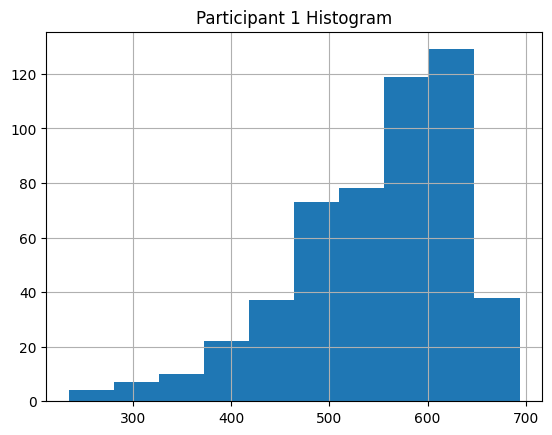

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -2.8475
  L2-R2                    : -0.4851
  Incoming Direction       : 0.5191


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.9373
  L2-R2                    : -0.6867
  Incoming Direction       : 0.0881


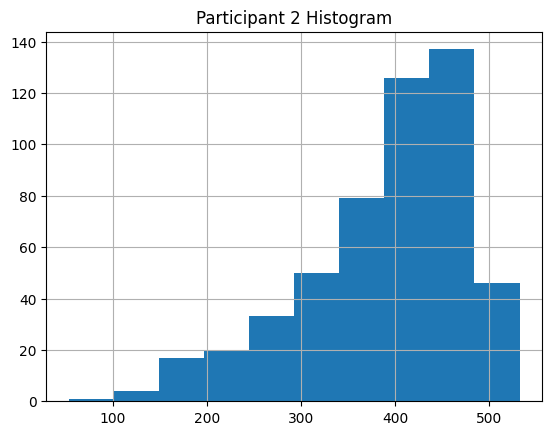

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.3948
  L2-R2                    : -0.5474
  Incoming Direction       : -0.6471


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -0.6145
  L2-R2                    : -0.0332
  Incoming Direction       : -1.2836


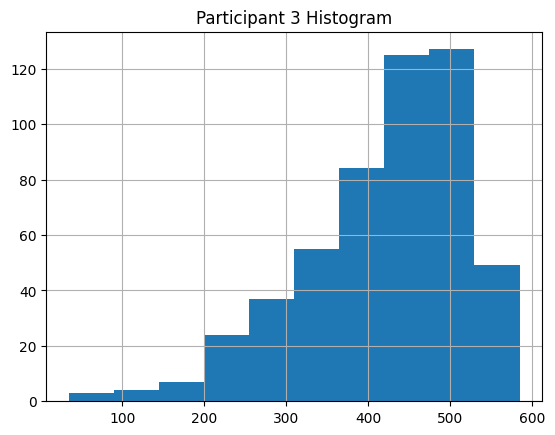

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -2.2742
  L2-R2                    : -0.0153
  Incoming Direction       : -0.2747


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.0684
  L2-R2                    : -0.7214
  Incoming Direction       : -0.5017


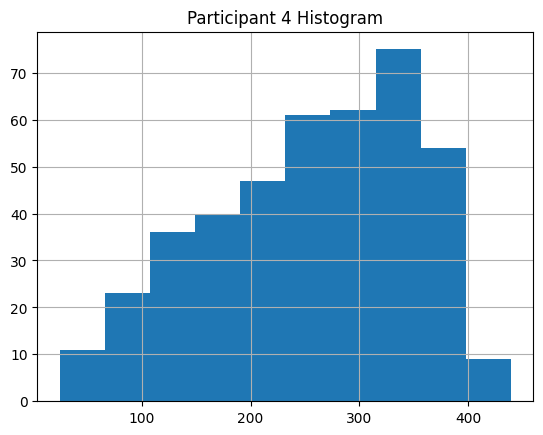

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -52.4019
  L2-R2                    : -10.2897
  Incoming Direction       : 2.2897


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -2.4359
  L2-R2                    : 0.3830
  Incoming Direction       : 0.3862


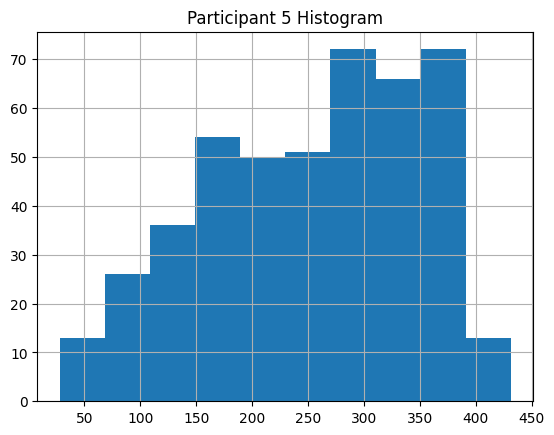

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.6135
  L2-R2                    : -0.6357
  Incoming Direction       : -0.9180


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -0.7378
  L2-R2                    : -0.0580
  Incoming Direction       : -2.2244


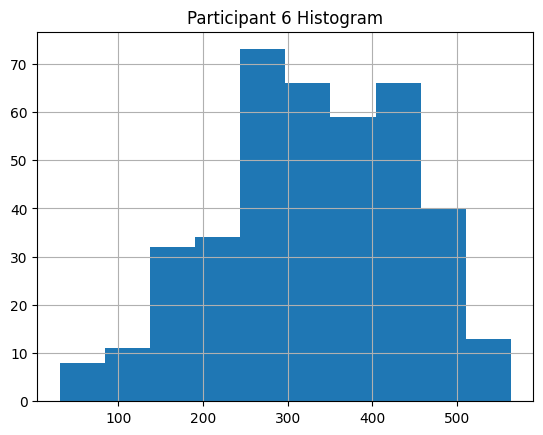

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -0.4406
  L2-R2                    : -0.9369
  Incoming Direction       : -2.0150


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -0.1407
  L2-R2                    : 0.4272
  Incoming Direction       : -0.9883


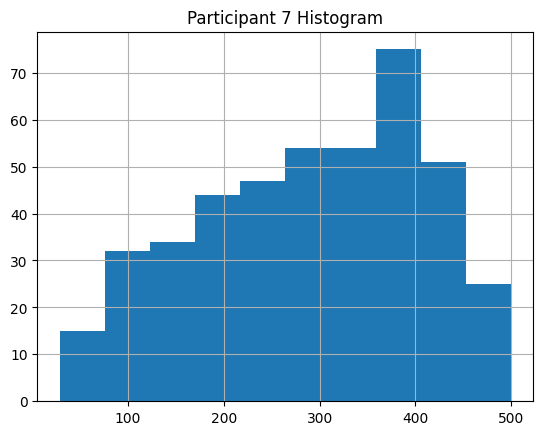

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.5570
  L2-R2                    : -1.6765
  Incoming Direction       : -1.2823


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -3.2906
  L2-R2                    : -1.9924
  Incoming Direction       : -1.2856


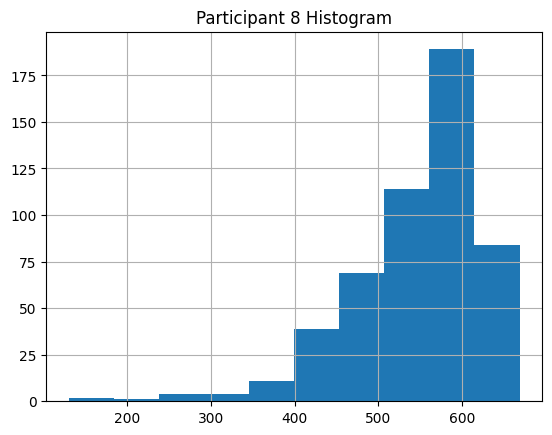

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.1394
  L2-R2                    : -0.4883
  Incoming Direction       : 0.3814


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -0.6840
  L2-R2                    : -0.1610
  Incoming Direction       : -0.3610


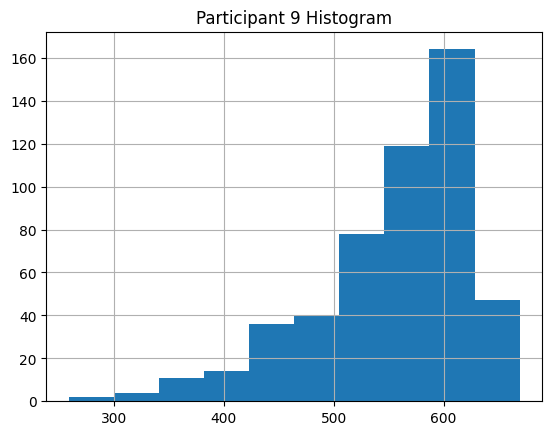

Ball is high on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -3.7876
  L2-R2                    : 0.3177
  Incoming Direction       : 0.1847


Ball is low on the screen:

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -2.1721
  L2-R2                    : 0.0822
  Incoming Direction       : -0.5028


In [ ]:
participants_data = [
    participant1, participant2, participant3, 
    participant4, participant5, participant6, 
    participant7, participant8, participant9
]

for i, p_data in enumerate(participants_data):
    input_data = pre_proccess_data_from_choice_vs_no_choice(p_data)
    input_data = input_data[input_data['block_drift'] == 1]
    input_data['ball_y_at_top'].hist()
    plt.title(f'Participant {i+1} Histogram')
    plt.show()
    
    LowY = input_data['ball_y_at_top'].quantile(0.25)
    HighY = input_data['ball_y_at_top'].quantile(0.75)

    low_pos_X = input_data[(input_data['ball_y_at_top'] < LowY) & (input_data['block_drift'] == 1)]
    #print(low_pos_X.shape)
    high_pos_X = input_data[(input_data['ball_y_at_top'] > HighY) & (input_data['block_drift'] == 1)]
    #print(high_pos_X.shape)

    print('Ball is high on the screen:')
    evaluate_logistic_for_ball_y(low_pos_X, is_data_raw = False)
    print('\n\nBall is low on the screen:')
    evaluate_logistic_for_ball_y(high_pos_X, is_data_raw= False)




In [42]:
def extract_spatial_features(df_raw, participant_name):
    """Applies spatial math and extracts block_drift for condition splitting."""
    if df_raw is None or df_raw.empty:
        return pd.DataFrame()

    is_left = df_raw['chosen_left'].astype(bool)
    
    L1 = np.where(is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    R1 = np.where(~is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    
    chosen_2step_diff = df_raw['chosen_2step_dist'] - df_raw['chosen_1step_dist']
    unchosen_2step_diff = df_raw['unchosen_2step_dist'] - df_raw['unchosen_1step_dist']
    
    L2 = np.where(is_left, chosen_2step_diff, unchosen_2step_diff)
    R2 = np.where(~is_left, chosen_2step_diff, unchosen_2step_diff)

    X = pd.DataFrame({
        'participant': participant_name,
        'L1-R1': np.round(L1 - R1), 
        'L2-R2': np.round(L2 - R2),
        'block_drift': df_raw['block_drift'], # 👈 Pulled into the clean matrix
        'chosen_right': (~is_left).astype(float) 
    })
    
    X = X.dropna(subset=['L1-R1', 'L2-R2', 'block_drift', 'chosen_right']).copy()
    
    X['L1-R1'] = X['L1-R1'].astype(int)
    X['L2-R2'] = X['L2-R2'].astype(int)
    
    return X

participants_data = [
    participant1, participant2, participant3, 
    participant4, participant5, participant6, 
    participant7, participant8, participant9
]

all_trials = []
for i, p_data in enumerate(participants_data):
    all_trials.append(extract_spatial_features(pre_proccess_data_from_choice_vs_no_choice(p_data), f'Participant {i+1}'))

df_combined = pd.concat(all_trials, ignore_index=True)


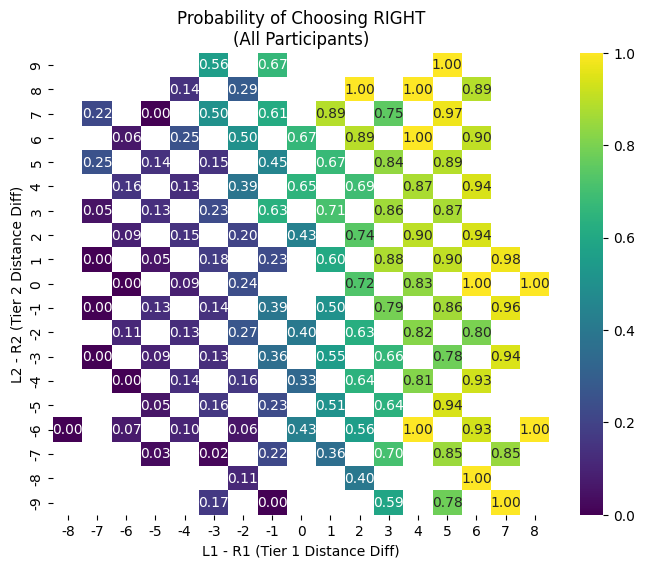

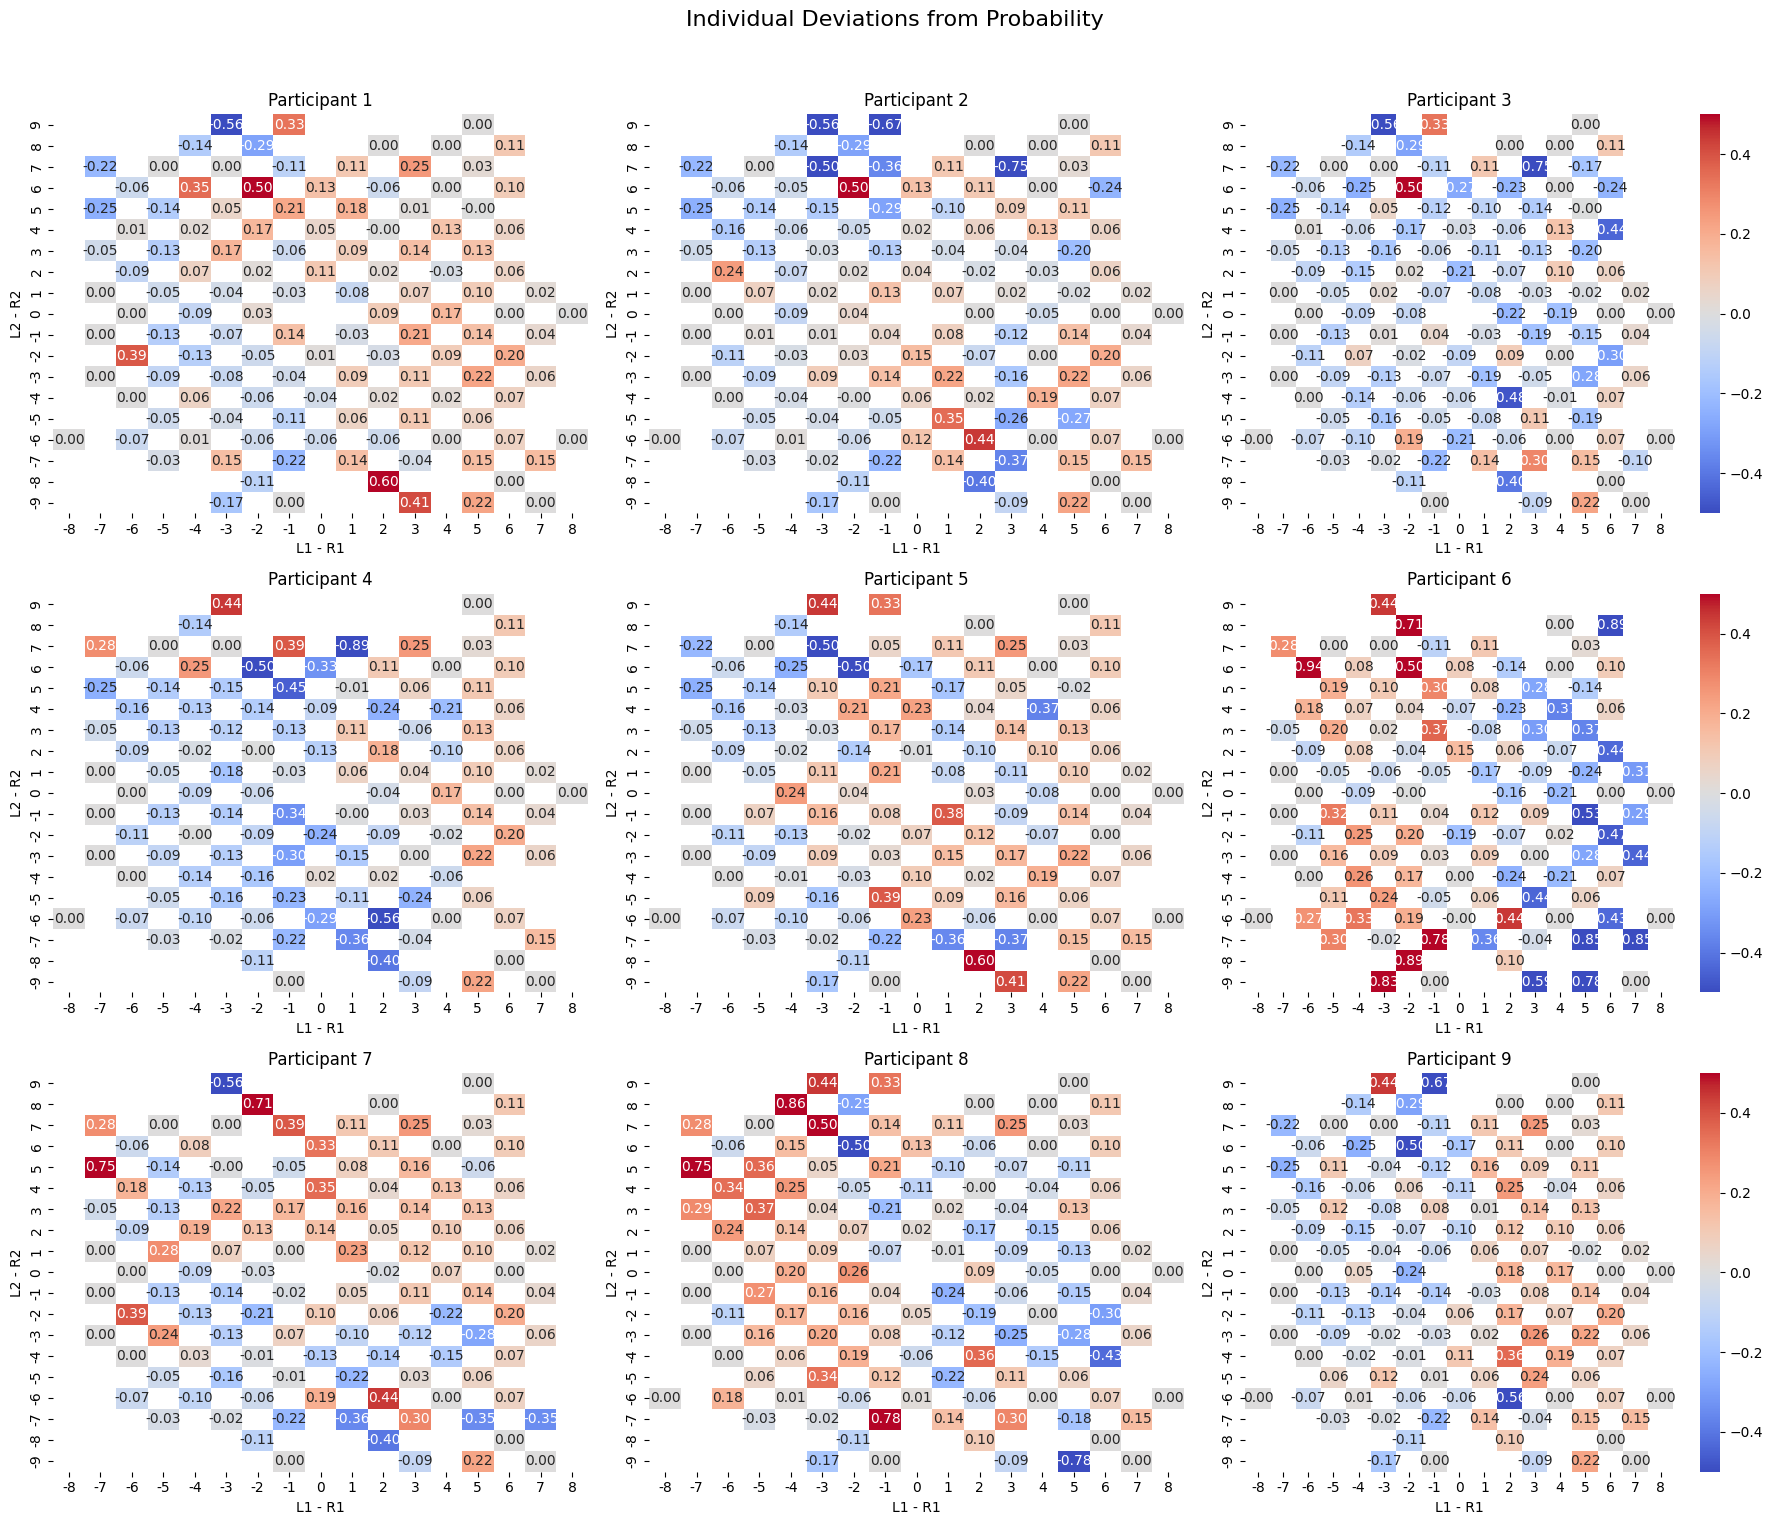

In [46]:
master_pivot = df_combined.pivot_table(
    values='chosen_right', 
    index='L2-R2', 
    columns='L1-R1', 
    aggfunc='mean'
)

# Sort index so positive L2-R2 values are at the top of the heatmap
master_pivot = master_pivot.sort_index(ascending=False)

# 3. Plot the Master Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(master_pivot, annot=True, cmap='viridis', fmt=".2f", vmin=0, vmax=1)
plt.title("Probability of Choosing RIGHT\n(All Participants)")
plt.ylabel("L2 - R2 (Tier 2 Distance Diff)")
plt.xlabel("L1 - R1 (Tier 1 Distance Diff)")
plt.show()

# 4. Build and Plot the Deviation Heatmaps
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle("Individual Deviations from Probability", fontsize=16, y=0.95)
axes = axes.flatten()

for i in range(9):
    p_name = f'Participant {i+1}'
    p_df = df_combined[df_combined['participant'] == p_name]
    
    # Create the individual's pivot table
    p_pivot = p_df.pivot_table(
        values='chosen_right', 
        index='L2-R2', 
        columns='L1-R1', 
        aggfunc='mean'
    )
    
    # Align the individual grid to match the master grid shape perfectly
    # (Fills NaN if a participant didn't experience a specific grid state)
    p_pivot = p_pivot.reindex_like(master_pivot)
    
    # Calculate Deviation (Participant Prob - Master Prob)
    deviation_matrix = p_pivot - master_pivot
    
    # Plot using a diverging colormap centered at 0
    sns.heatmap(
        deviation_matrix, 
        ax=axes[i], 
        annot=True, 
        cmap='coolwarm', 
        fmt=".2f", 
        center=0, 
        vmin=-0.5, 
        vmax=0.5, # Cap color scale at +/- 50% deviation for contrast
        cbar=(i % 3 == 2) # Only show colorbar on the rightmost plots to save space
    )
    
    axes[i].set_title(p_name)
    axes[i].set_ylabel("L2 - R2")
    axes[i].set_xlabel("L1 - R1")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

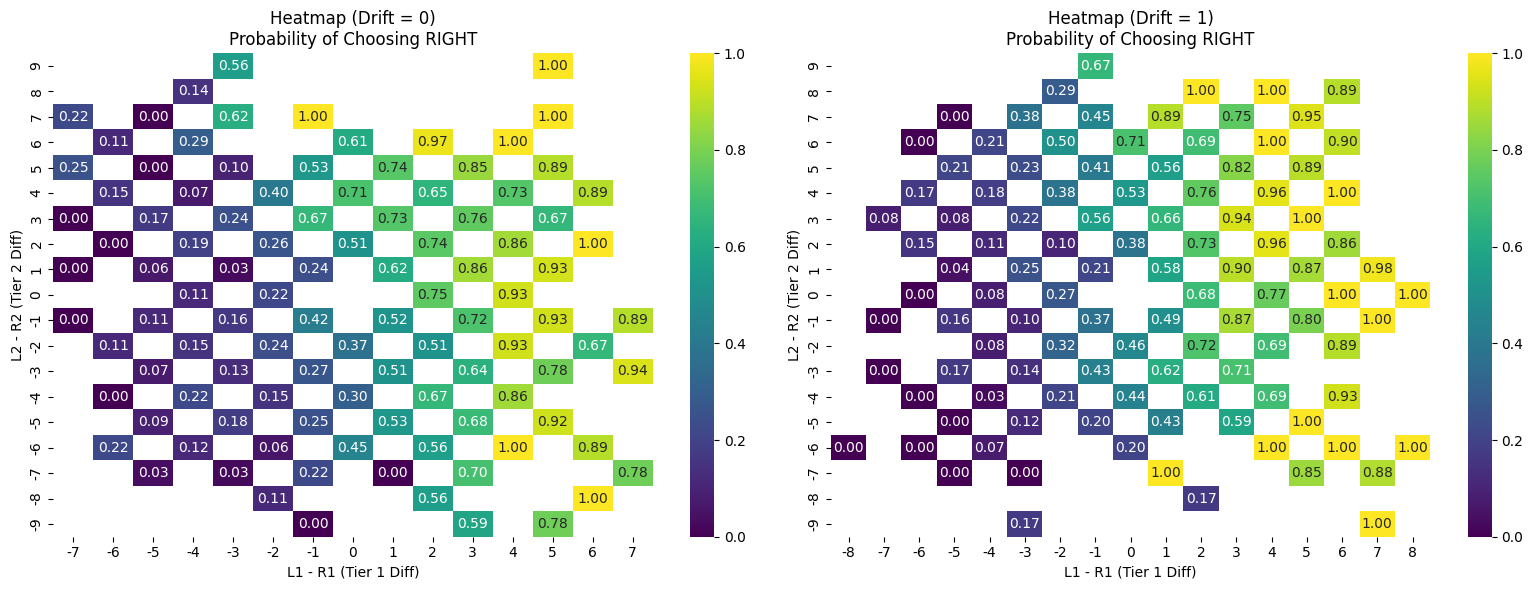

In [47]:
df_drift_0 = df_combined[df_combined['block_drift'] == 0]
df_drift_1 = df_combined[df_combined['block_drift'] == 1]

# Create both master pivot tables
master_pivot_0 = df_drift_0.pivot_table(values='chosen_right', index='L2-R2', columns='L1-R1', aggfunc='mean').sort_index(ascending=False)
master_pivot_1 = df_drift_1.pivot_table(values='chosen_right', index='L2-R2', columns='L1-R1', aggfunc='mean').sort_index(ascending=False)

# Plot Both Master Heatmaps Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(master_pivot_0, ax=axes[0], annot=True, cmap='viridis', fmt=".2f", vmin=0, vmax=1)
axes[0].set_title("Heatmap (Drift = 0)\nProbability of Choosing RIGHT")
axes[0].set_ylabel("L2 - R2 (Tier 2 Diff)")
axes[0].set_xlabel("L1 - R1 (Tier 1 Diff)")

sns.heatmap(master_pivot_1, ax=axes[1], annot=True, cmap='viridis', fmt=".2f", vmin=0, vmax=1)
axes[1].set_title("Heatmap (Drift = 1)\nProbability of Choosing RIGHT")
axes[1].set_ylabel("L2 - R2 (Tier 2 Diff)")
axes[1].set_xlabel("L1 - R1 (Tier 1 Diff)")

plt.tight_layout()
plt.show()



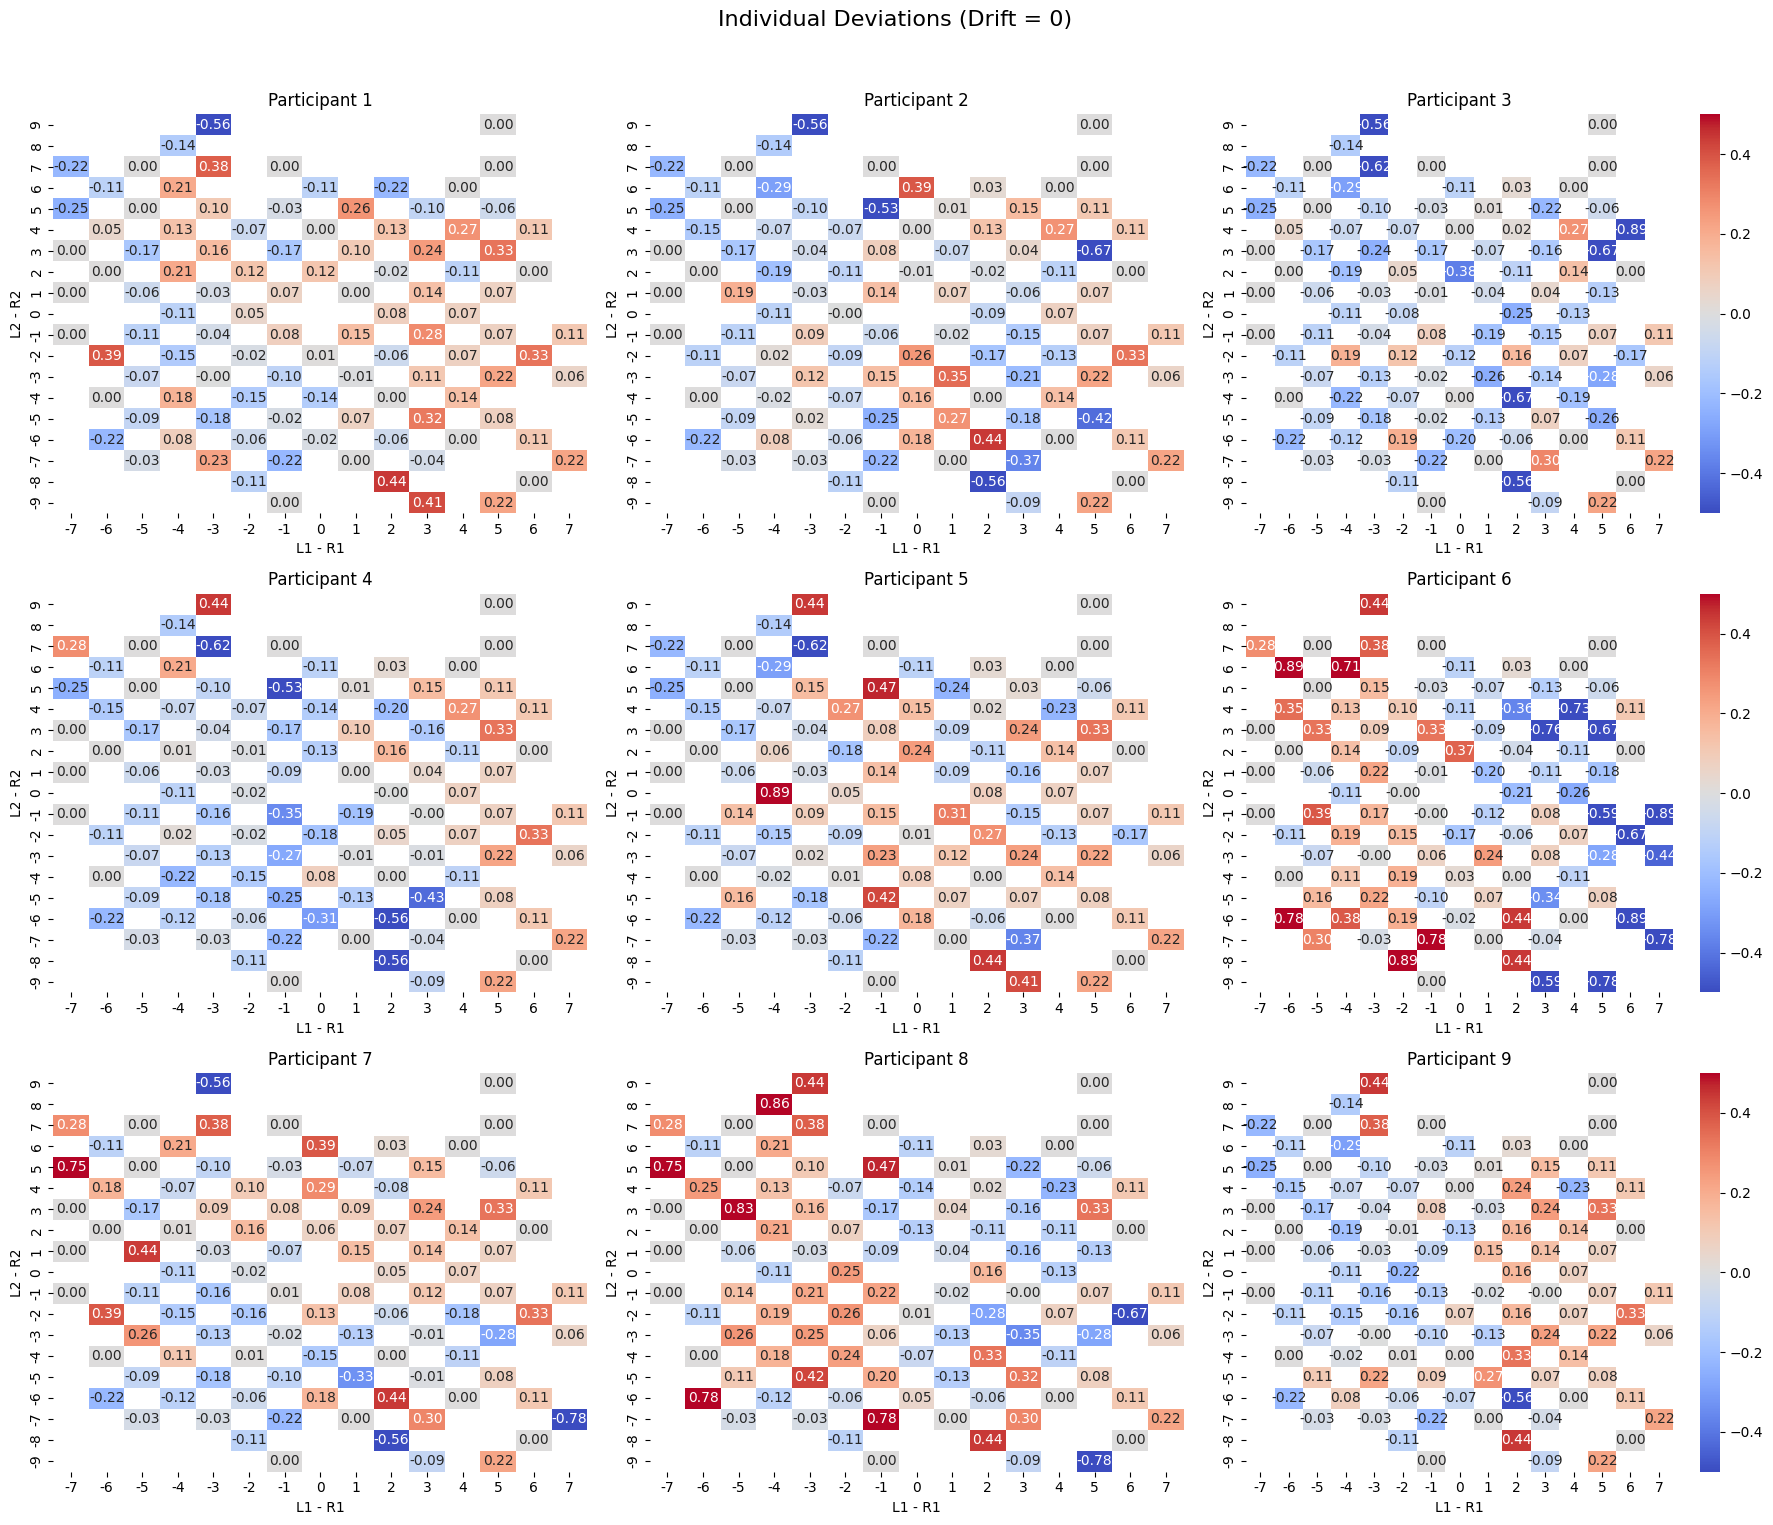

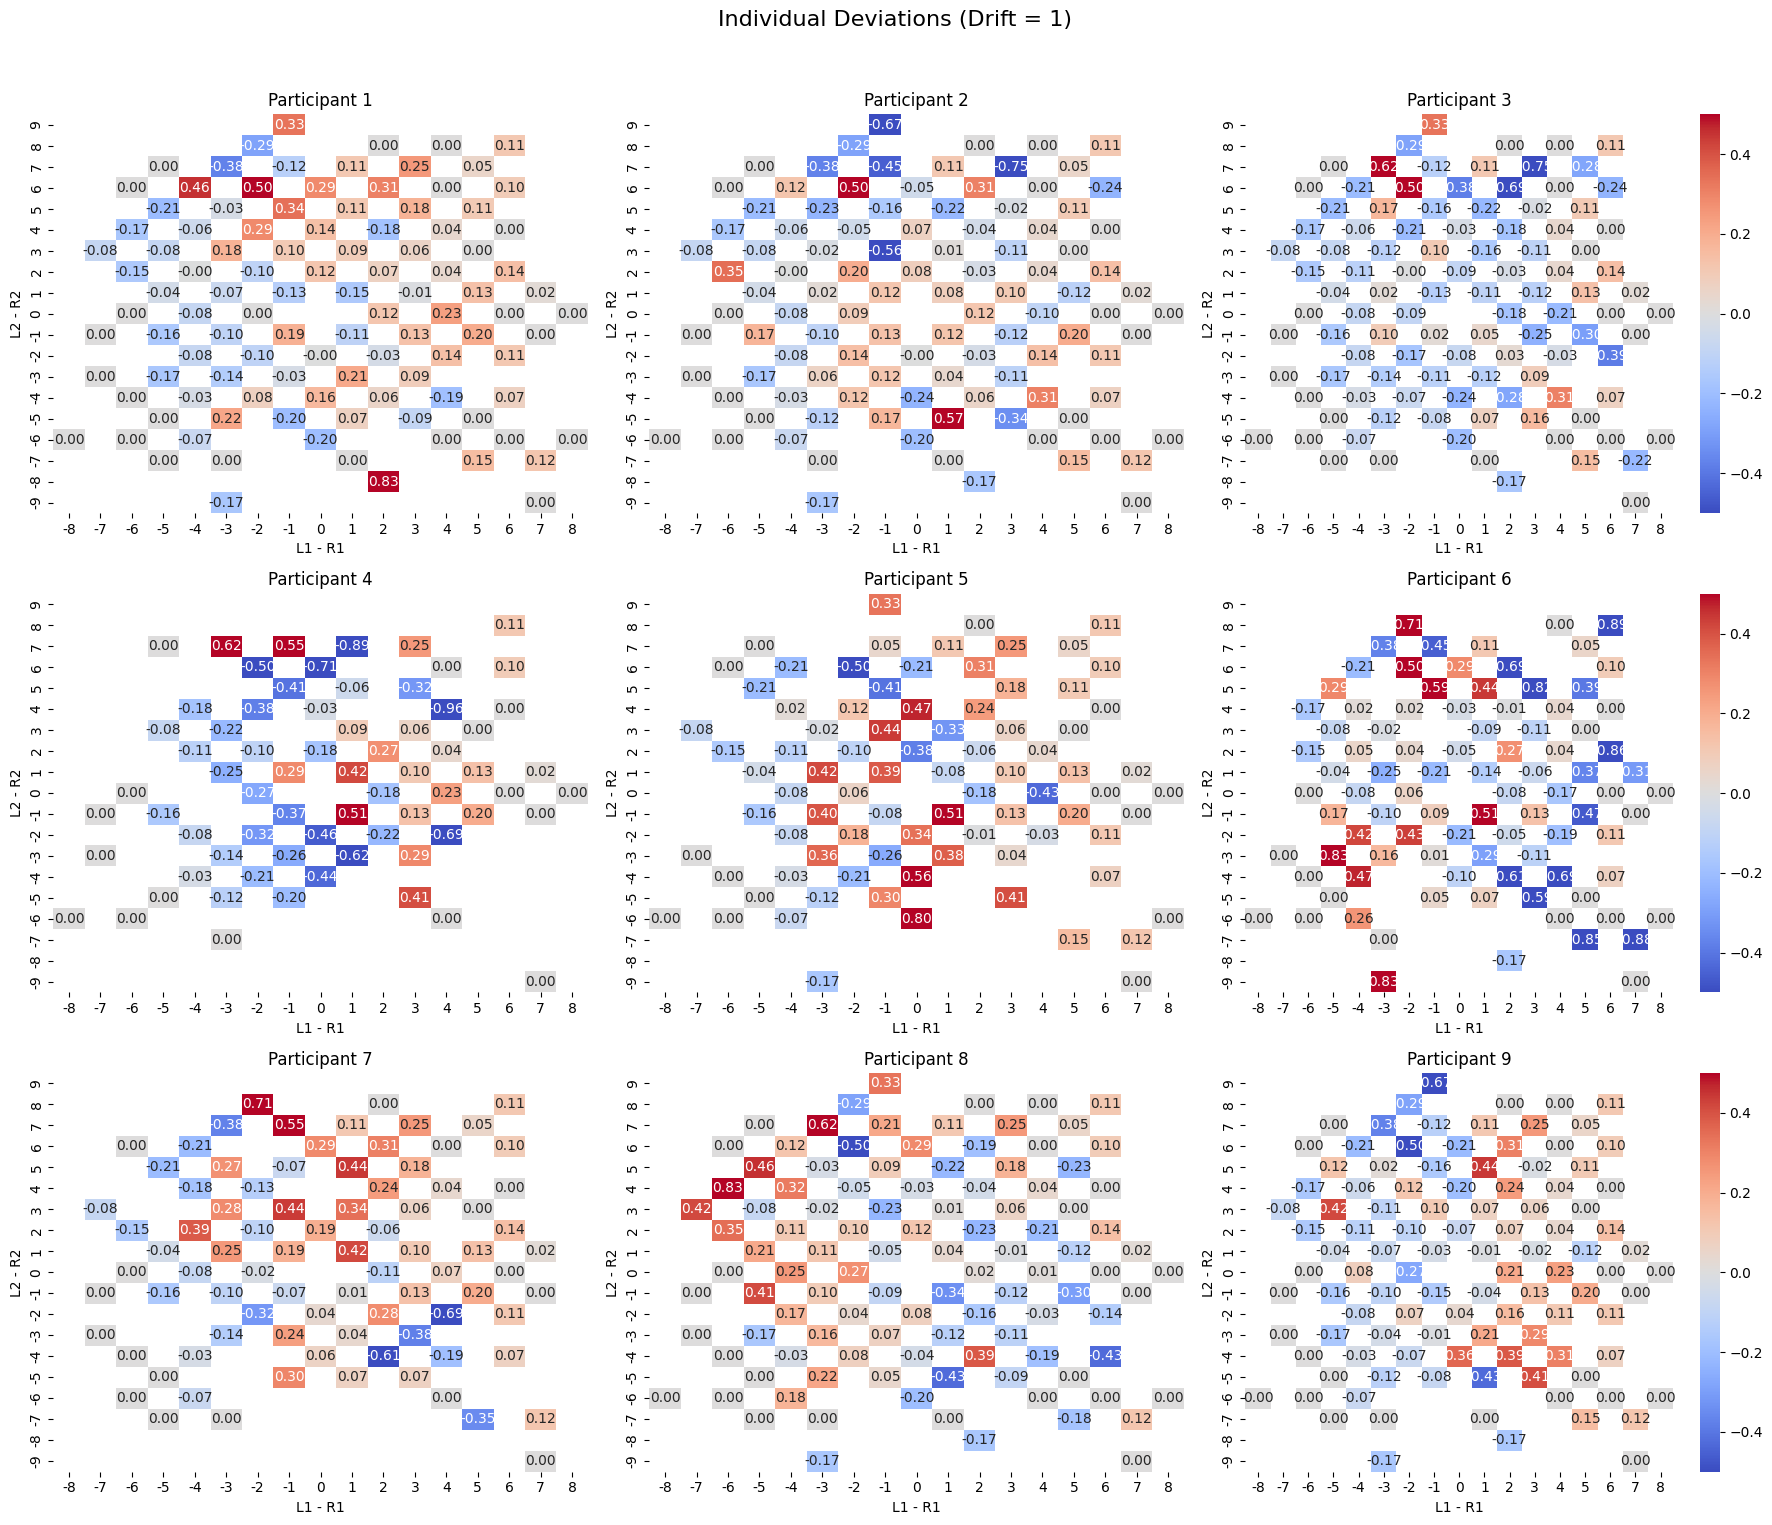

In [48]:
def plot_deviations_for_condition(df_subset, master_pivot, condition_label):
    """Generates a 3x3 grid of participant deviations for a specific drift condition."""
    fig, axes = plt.subplots(3, 3, figsize=(18, 16))
    fig.suptitle(f"Individual Deviations (Drift = {condition_label})", fontsize=16, y=0.95)
    axes = axes.flatten()

    for i in range(9):
        p_name = f'Participant {i+1}'
        p_df = df_subset[df_subset['participant'] == p_name]
        
        if p_df.empty:
            axes[i].set_title(f"{p_name}\n(No Data)")
            axes[i].axis('off')
            continue
            
        # Create the individual's pivot table for this drift condition
        p_pivot = p_df.pivot_table(values='chosen_right', index='L2-R2', columns='L1-R1', aggfunc='mean')
        
        # Align to the specific master grid for this condition
        p_pivot = p_pivot.reindex_like(master_pivot)
        
        # Calculate Deviation
        deviation_matrix = p_pivot - master_pivot
        
        sns.heatmap(
            deviation_matrix, 
            ax=axes[i], 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            center=0, 
            vmin=-0.5, 
            vmax=0.5, 
            cbar=(i % 3 == 2) 
        )
        
        axes[i].set_title(p_name)
        axes[i].set_ylabel("L2 - R2")
        axes[i].set_xlabel("L1 - R1")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# Execute the deviation plots for both conditions
plot_deviations_for_condition(df_drift_0, master_pivot_0, "0")
plot_deviations_for_condition(df_drift_1, master_pivot_1, "1")

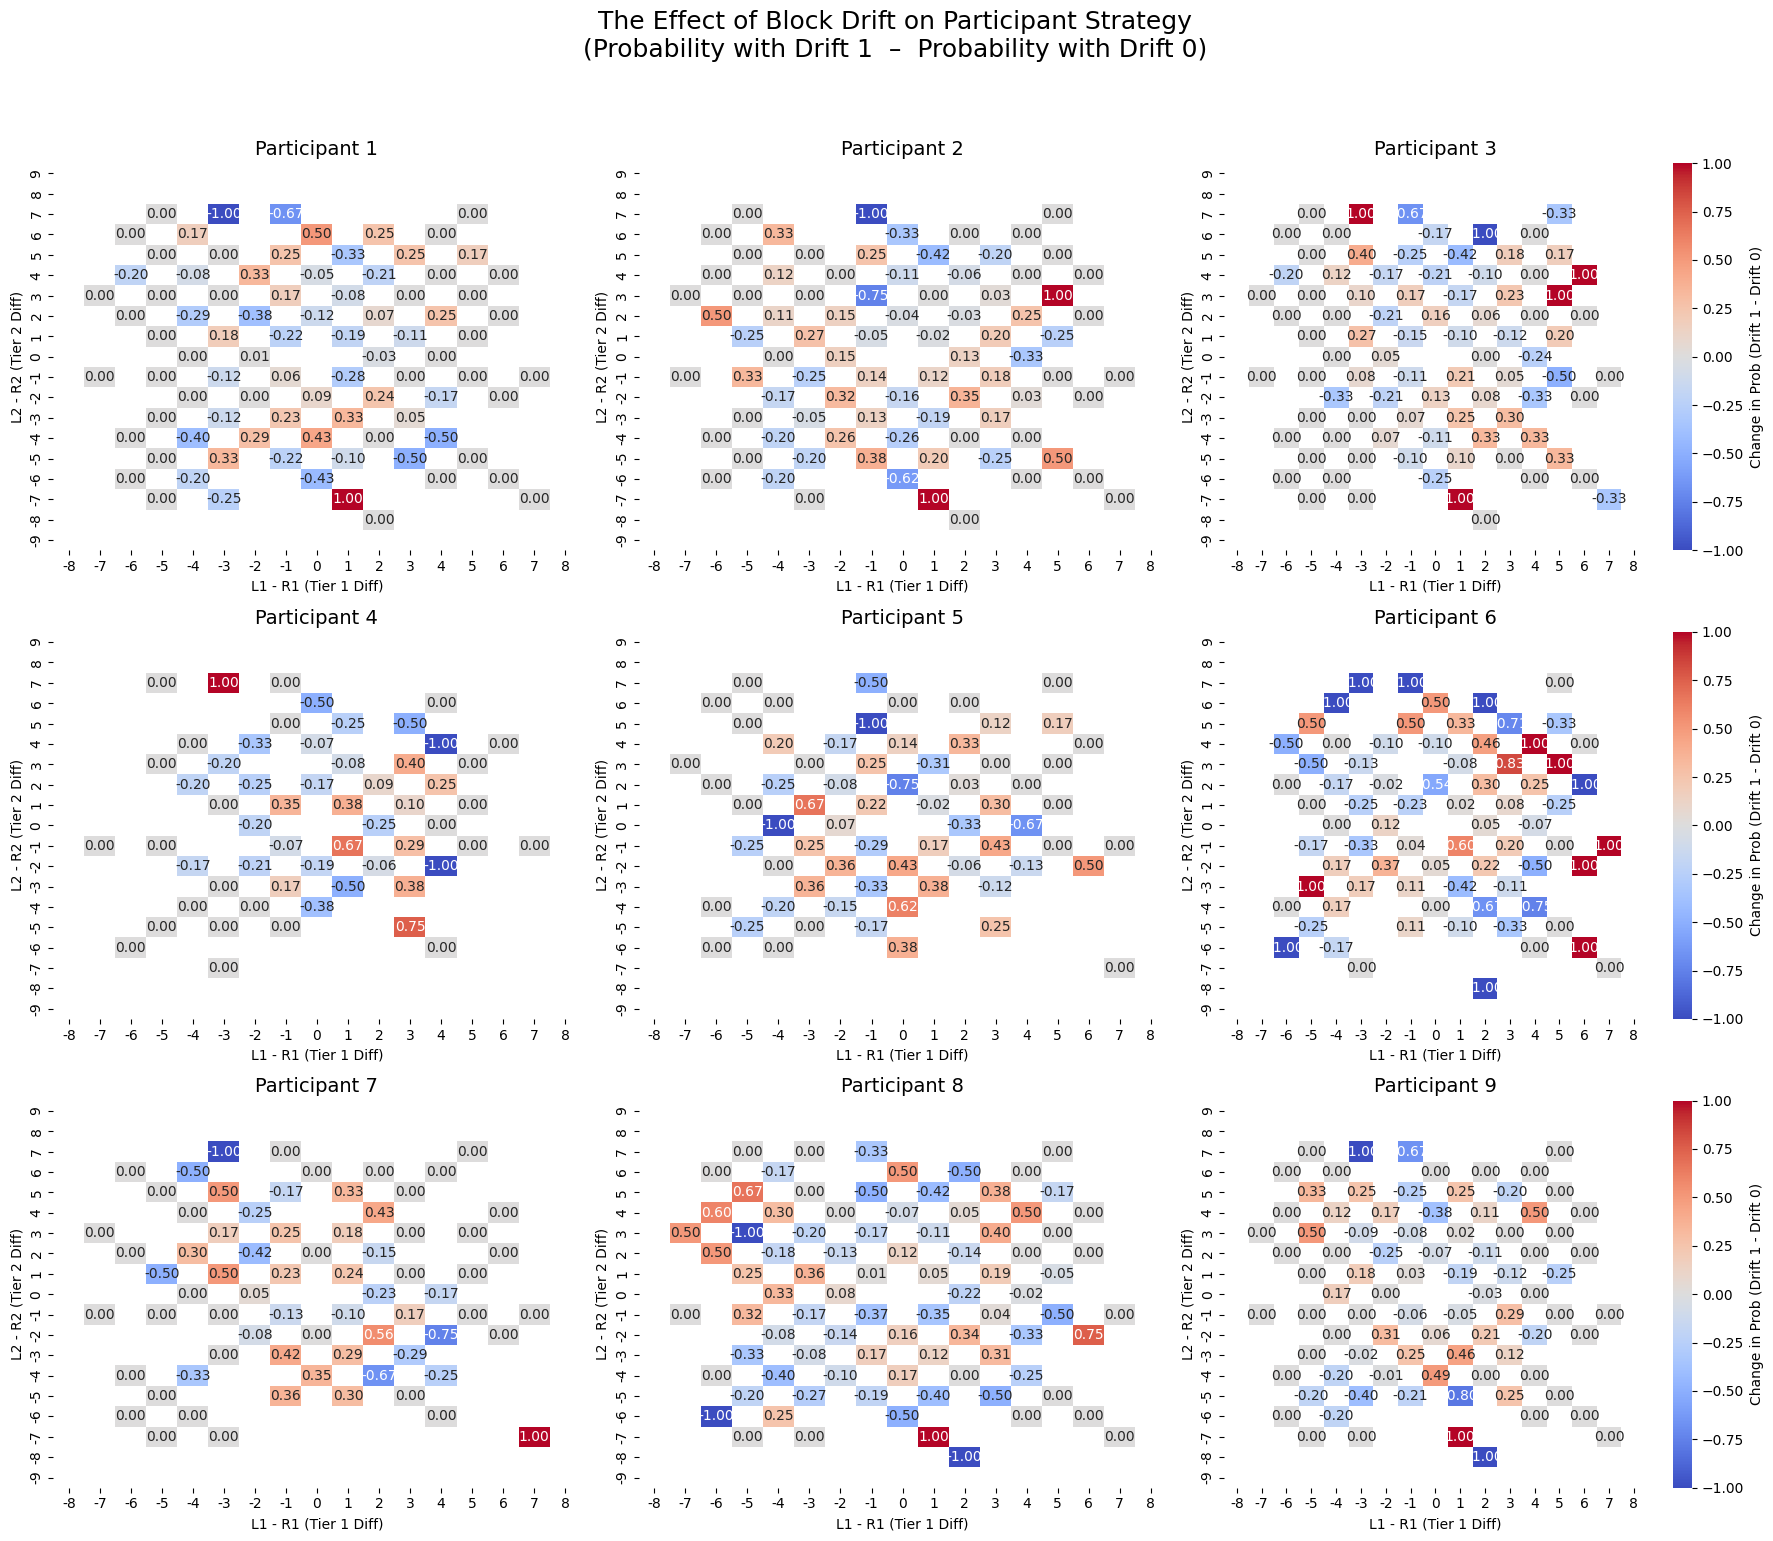

In [88]:
def plot_individual_drift_effects(df_combined):
    """
    Plots a 3x3 grid showing how the introduction of Block Drift changed 
    each participant's probability of choosing Right.
    """
    fig, axes = plt.subplots(3, 3, figsize=(18, 16))
    fig.suptitle("The Effect of Block Drift on Participant Strategy\n(Probability with Drift 1  –  Probability with Drift 0)", fontsize=18, y=0.96)
    axes = axes.flatten()

    # Generate a global master template to ensure all matrices align perfectly
    # (Even if a participant didn't see a specific coordinate in one condition)
    master_template = df_combined.pivot_table(
        values='chosen_right', 
        index='L2-R2', 
        columns='L1-R1'
    ).sort_index(ascending=False)

    for i in range(9):
        p_name = f'Participant {i+1}'
        
        # Isolate the specific participant's data for both conditions
        p_drift_0 = df_combined[(df_combined['participant'] == p_name) & (df_combined['block_drift'] == 0)]
        p_drift_1 = df_combined[(df_combined['participant'] == p_name) & (df_combined['block_drift'] == 1)]
        
        # Safety Check: If they are missing data for an entire condition, skip plotting
        if p_drift_0.empty or p_drift_1.empty:
            axes[i].set_title(f"{p_name}\n(Insufficient Data for Comparison)")
            axes[i].axis('off')
            continue
            
        # Pivot both conditions
        pivot_0 = p_drift_0.pivot_table(values='chosen_right', index='L2-R2', columns='L1-R1', aggfunc='mean')
        pivot_1 = p_drift_1.pivot_table(values='chosen_right', index='L2-R2', columns='L1-R1', aggfunc='mean')
        
        # Reindex to force them into the exact same shape
        pivot_0 = pivot_0.reindex_like(master_template)
        pivot_1 = pivot_1.reindex_like(master_template)
        
        # Calculate the true effect of the drift
        drift_impact_matrix = pivot_1 - pivot_0
        
        # Plot using a diverging colormap centered at 0
        sns.heatmap(
            drift_impact_matrix,
            ax=axes[i],
            annot=True,
            cmap='coolwarm', # Red = Increased Right Prob, Blue = Increased Left Prob
            fmt=".2f",
            center=0,
            vmin=-1.0,  # Probabilities max out at 1.0, so the absolute max difference is +/- 1.0
            vmax=1.0,
            cbar=(i % 3 == 2), # Only show colorbar on the rightmost plots
            cbar_kws={'label': 'Change in Prob (Drift 1 - Drift 0)'} if (i % 3 == 2) else None
        )
        
        axes[i].set_title(p_name, fontsize=14)
        axes[i].set_ylabel("L2 - R2 (Tier 2 Diff)")
        axes[i].set_xlabel("L1 - R1 (Tier 1 Diff)")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


plot_individual_drift_effects(df_combined)